# Параметрическая серия и стохастические повторы
Дополнение §6.2: девять сочетаний β/γ, по 20 независимых SSA-траекторий.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("SIRPetri.jl"))
using .SIRPetri
include(srcdir("experiment_support.jl"))

animate_sir

## План: 3 × 3 сочетания и воспроизводимые seed

In [2]:
betas, gammas = [0.1, 0.3, 0.8], [0.05, 0.1, 0.2]
repeats = 20
rows = NamedTuple[]
det_rows = NamedTuple[]
for (case_id, (β, γ)) in enumerate(Iterators.product(betas, gammas))
    net, u0, _ = build_sir_network(β, γ)
    det = simulate_deterministic(net, u0, (0.0, 100.0); saveat=0.5, rates=[β, γ])
    peak = refined_peak(net, u0, (0.0, 100.0); rates=[β, γ])
    push!(det_rows, merge((case_id=case_id, β=β, γ=γ, refined_peak=peak.peak), epidemic_summary(det)))
    save_table("parameters/det_$(case_id).csv", det)
    for repetition in 1:repeats
        seed = 123 + 100case_id + repetition
        stoch = simulate_stochastic(net, u0, (0.0, 100.0);
            rates=[β, γ], rng=Xoshiro(seed))
        push!(rows, merge((case_id=case_id, β=β, γ=γ, repetition=repetition, seed=seed),
            epidemic_summary(stoch)))
        repetition == 1 && save_table("parameters/ssa_$(case_id).csv", stoch)
    end
end
ensemble = DataFrame(rows)
deterministic = DataFrame(det_rows)
save_table("sir_param_replicates.csv", ensemble)
save_table("sir_param_deterministic.csv", deterministic)
first(ensemble, 10)

Row,case_id,β,γ,repetition,seed,peak_I,peak_time,final_R,conservation_error
,Int64,Float64,Float64,Int64,Int64,Int64,Float64,Int64,Int64
1,1,0.1,0.05,1,224,997,0.111796,994,0
2,1,0.1,0.05,2,225,997,0.113862,988,0
3,1,0.1,0.05,3,226,998,0.12233,995,0
4,1,0.1,0.05,4,227,996,0.110886,993,0
5,1,0.1,0.05,5,228,993,0.146115,992,0
6,1,0.1,0.05,6,229,996,0.0871714,991,0
7,1,0.1,0.05,7,230,997,0.101043,997,0
8,1,0.1,0.05,8,231,997,0.122466,997,0
9,1,0.1,0.05,9,232,997,0.112573,993,0


## Средние и стандартные отклонения, не доверительный интервал

In [3]:
summary = combine(groupby(ensemble, [:case_id, :β, :γ]),
    :peak_I => mean => :peak_mean, :peak_I => std => :peak_sd,
    :final_R => mean => :final_R_mean, :final_R => std => :final_R_sd,
    :peak_time => mean => :time_mean)
save_table("sir_param_summary.csv", summary)
summary

Row,case_id,β,γ,peak_mean,peak_sd,final_R_mean,final_R_sd,time_mean
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,0.1,0.05,996.85,1.87153,993.5,2.39517,0.120284
2,2,0.3,0.05,998.95,0.759155,993.15,3.16685,0.03995
3,3,0.8,0.05,999.6,0.598243,992.8,2.54641,0.0145504
4,4,0.1,0.1,993.35,2.41214,999.95,0.223607,0.108671
5,5,0.3,0.1,997.8,1.36111,999.9,0.307794,0.0412223
6,6,0.8,0.1,999.0,1.1698,999.95,0.223607,0.0155214
7,7,0.1,0.2,985.7,3.21346,1000.0,0.0,0.104662
8,8,0.3,0.2,996.0,1.52177,1000.0,0.0,0.0390938
9,9,0.8,0.2,998.55,1.09904,1000.0,0.0,0.0144826


## Изменение стохастического пика при разных скоростях

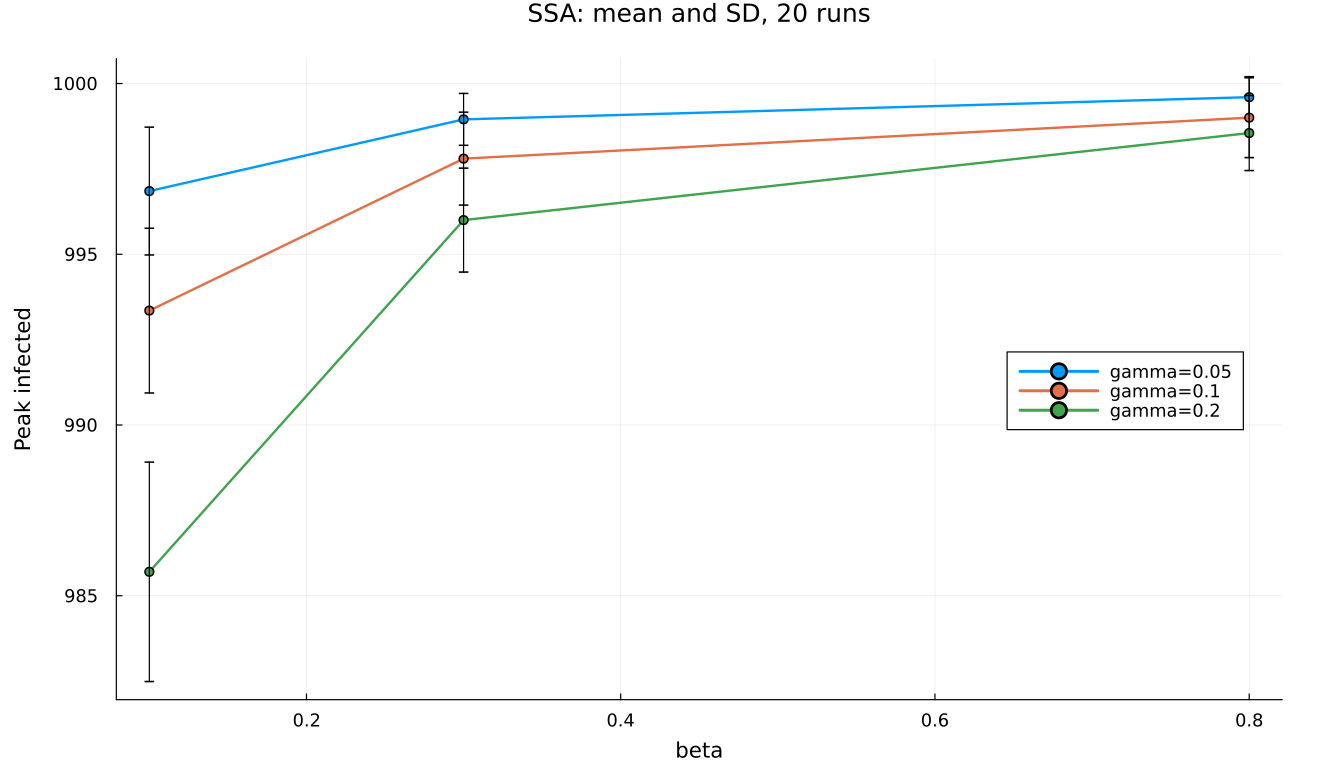

In [4]:
p_ensemble = plot(; xlabel="beta", ylabel="Peak infected", title="SSA: mean and SD, 20 runs")
for γ in gammas
    d = sort(summary[summary.γ .== γ, :], :β)
    plot!(p_ensemble, d.β, d.peak_mean; yerror=d.peak_sd, marker=:circle, label="gamma=$(γ)")
end
savefig(p_ensemble, imagepath("10-plot.png"))
display(p_ensemble)